# 14.3.1 从非线性状态到线性观测

## 学习目标与先修知识

构造恰好闭合的有限观测（observation）字典，手算并核验其线性传播。

先修：14.2 离散传播；函数复合与矩阵乘法（matrix multiplication）。

## 具体问题

状态（state）更新含 $x^2$ 时，原状态 $[x,y]$ 不是线性传播。若把 $x^2$ 也作为观测量，同一系统能否在扩展变量中线性更新？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from systems_science import plot_style
plot_style()
font_names={font.name for font in font_manager.fontManager.ttflist}
for name in ("Microsoft YaHei","SimHei","Noto Sans CJK SC"):
    if name in font_names:
        plt.rcParams["font.sans-serif"]=[name,"DejaVu Sans"]
        break
BLUE,PINK,GREEN="#008bfb","#ff0051","#00a56a"

## 初步实验

计算两个不同初值（initial condition）的一步更新，并比较其 $x^2$ 是否按固定倍数变化。

In [2]:
for initial in ([.5,.2],[1.5,.2]):
    x,y=initial;nxt=[.8*x,.7*y+.4*x*x]
    print('状态',initial,'→',nxt,'；平方观测',initial[0]**2,'→',nxt[0]**2)

状态 [0.5, 0.2] → [0.4, 0.24] ；平方观测 0.25 → 0.16000000000000003
状态 [1.5, 0.2] → [1.2000000000000002, 1.04] ；平方观测 2.25 → 1.4400000000000004


## 模型假设

选定离散教学系统 $x^+=ax$、$y^+=by+cx^2$，参数（parameter）常数且没有外部输入（input）。观测函数字典 $g=[x,y,x^2]^\mathsf T$ 由我们指定；字典闭合只对此模型（model）和这组三个函数成立。读出矩阵（matrix）抽取前两个分量。

## 数学解释与推导

Koopman 算子（Koopman operator）作用在观测函数 $g$ 上，定义 $(\mathcal K g)(s)=g(F(s))$；原状态映射 $F$ 可以非线性。这里 $z=[x,y,x^2]^\mathsf T$ 满足 $z^+=Kz$，其中 $K=\begin{bmatrix}a&0&0\\0&b&c\\0&0&a^2\end{bmatrix}$。第三行来自 $(x^+)^2=a^2x^2$，因而有限字典恰好闭合。状态读出 $Cz=[x,y]^\mathsf T$。一般非线性系统没有这种有限闭合，有限维近似必须检验字典误差与留出预测。

## 核心实现

以下是本节完整计算步骤，可逐行修改。

In [3]:
def triangular_step(state, a, b, c):
    """A nonlinear map whose [x,y,x²] lift closes exactly."""
    x, y = state
    return [a * x, b * y + c * x*x]


def triangular_lift(state):
    x, y = state
    return [x, y, x*x]


def edmd_fit(feature_past, feature_next, ridge):
    """Features are columns; K acts from the left on feature vectors."""
    x = np.asarray(feature_past, dtype=float)
    y = np.asarray(feature_next, dtype=float)
    if ridge == 0:
        return (y @ np.linalg.pinv(x, rcond=1e-12)).tolist()
    gram = x @ x.T + ridge * np.eye(x.shape[0])
    return np.linalg.solve(gram, x @ y.T).T.tolist()


def lifted_roll(operator, readout, initial_feature, steps):
    matrix = np.asarray(operator, dtype=float)
    output = np.asarray(readout, dtype=float)
    feature = np.asarray(initial_feature, dtype=float)
    states = [(output @ feature).tolist()]
    for _ in range(steps):
        feature = matrix @ feature
        states.append((output @ feature).tolist())
    return states

## 对照实验

用多个独立初值的配对观测拟合扩展动态模态分解（extended dynamic mode decomposition，EDMD）矩阵，与手算闭合矩阵及留出轨迹（trajectory）比较。

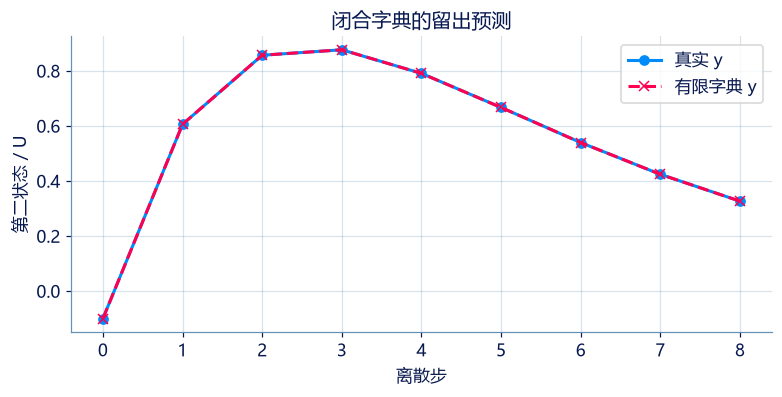

拟合矩阵： [[ 0.8  -0.    0.  ]
 [-0.    0.7   0.4 ]
 [ 0.   -0.    0.64]]


In [4]:
a,b,c=.8,.7,.4
starts=[[x,y] for x in [-1.,-.4,.4,1.] for y in [-.2,.3]]
Z=np.asarray([triangular_lift(s) for s in starts]).T
W=np.asarray([triangular_lift(triangular_step(s,a,b,c)) for s in starts]).T
K=np.asarray(edmd_fit(Z,W,0.));expected=np.array([[a,0,0],[0,b,c],[0,0,a*a]])
C=np.array([[1.,0.,0.],[0.,1.,0.]])
hold=[1.3,-.1];state=hold.copy();truth=[state]
for _ in range(8):state=triangular_step(state,a,b,c);truth.append(state)
pred=np.asarray(lifted_roll(K,C,triangular_lift(hold),8));truth=np.asarray(truth)
fig,ax=plt.subplots(figsize=(7,3.5));ax.plot(truth[:,1],'o-',label='真实 y',color=BLUE);ax.plot(pred[:,1],'x--',label='有限字典 y',color=PINK)
ax.set(xlabel='离散步',ylabel='第二状态 / U',title='闭合字典的留出预测');ax.legend();ax.grid(alpha=.25);plt.show()
print('拟合矩阵：',np.round(K,5))

## 结果解释

本例的三项字典专门针对已知代数结构设计，因而拟合矩阵和留出轨迹都可与真值一致。这是可核验的有限闭合实例，不意味着任意扩充字典都能线性化（linearization）任意非线性系统。

### 独立核对

逐项核对 $x^2$ 的更新、矩阵系数和留出多步误差。

In [5]:
np.testing.assert_allclose(K,expected,atol=1e-12)
np.testing.assert_allclose(pred,truth,atol=1e-12)
np.testing.assert_allclose(triangular_lift(triangular_step(hold,a,b,c)),expected@triangular_lift(hold))
print('代数闭合、回归与留出轨迹核验通过。')

代数闭合、回归与留出轨迹核验通过。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/14-03-Koopman%20%E8%A1%A8%E7%A4%BA%E4%B8%8E%E6%9C%89%E9%99%90%E5%AD%97%E5%85%B8/explore/)，再返回此处核对完整推导。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：从观测特征拟合传播

feature_past 与 feature_next 以列对应。返回左乘特征列的传播矩阵（matrix） K；ridge=0 时使用题定伪逆（pseudoinverse），ridge>0 时用岭式矩阵解。

**函数与代码模板**

```python
def solve(
    feature_past: list[list[float]],
    feature_next: list[list[float]],
    ridge: float,
) -> list[list[float]]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `feature_past` | `list[list[float]]` | d×m 旧特征列。 | 按特征声明 |
| `feature_next` | `list[list[float]]` | d×m 新特征列。 | 按特征声明 |
| `ridge` | `float` | 非负岭参数（parameter）。 | 按特征尺度 |

**返回值**

直接返回 operator（list[list[float]]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `operator` | `list[list[float]]` | d×d 特征传播矩阵。 | 按特征尺度 |

**计算规则**

ridge=0：K=Y·pinv(X)，伪逆相对阈值10⁻¹²；ridge>0：K=YXᵀ(XXᵀ+ridge·I)⁻¹。输入（input）特征已按题意构造，不在函数内重复提升。

**约束与边界**

- 特征矩阵同形且 d,m≥1；ridge≥0；全部数值有限。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| feature_past | d×m 旧特征列。 | [[1.0, 0.0], [0.0, 1.0]] | 按特征声明 |
| feature_next | d×m 新特征列。 | [[0.8, 0.0], [0.4, 0.7]] | 按特征声明 |
| ridge | 非负岭参数（parameter）。 | 0 | 按特征尺度 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
feature_past = [[1.0, 0.0], [0.0, 1.0]]
feature_next = [[0.8, 0.0], [0.4, 0.7]]
ridge = 0.0

result = solve(feature_past, feature_next, ridge)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| operator | d×d 特征传播矩阵。 | [[0.8, 0.0], [0.4, 0.7]] | 按特征尺度 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [[0.8, 0.0], [0.4, 0.7]]
```

**样例解释**

首例旧特征是单位矩阵（identity matrix），因而 K 等于新特征矩阵；正则化（regularization）会收缩系数。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：从观测特征拟合传播](http://127.0.0.1:8000/chapters/14-03-Koopman%20%E8%A1%A8%E7%A4%BA%E4%B8%8E%E6%9C%89%E9%99%90%E5%AD%97%E5%85%B8/practice/?question=p14-edmd-fit)

### 第 2 题 · 单项选择题：算子作用在哪里

Koopman 算子在本节怎样定义？

- **A.** 把观测（observation）函数与状态（state）映射复合，即 Kg=g∘F。
- **B.** 要求原状态 F 必须线性。
- **C.** 只能作用于固定的三个多项式。
- **D.** 自动证明字典的物理因果意义。

[作答：算子作用在哪里](http://127.0.0.1:8000/chapters/14-03-Koopman%20%E8%A1%A8%E7%A4%BA%E4%B8%8E%E6%9C%89%E9%99%90%E5%AD%97%E5%85%B8/practice/?question=p14-koopman-functions)

### 第 3 题 · 单项选择题：三角映射为何闭合

x⁺=ax，y⁺=by+cx²。字典 [x,y,x²] 的第三项下一步为何仍在字典中？

- **A.** (x⁺)²=a²x²。
- **B.** (x⁺)²=ay。
- **C.** 因为任何多项式字典都必闭合。
- **D.** 因为训练样本足够多就自动闭合。

[作答：三角映射为何闭合](http://127.0.0.1:8000/chapters/14-03-Koopman%20%E8%A1%A8%E7%A4%BA%E4%B8%8E%E6%9C%89%E9%99%90%E5%AD%97%E5%85%B8/practice/?question=p14-exact-closure)

### 第 4 题 · 单项选择题：状态读出的作用

已经得到 z=[x,y,x²] 的传播，如何在本例返回原状态（state）？

- **A.** 用固定读出矩阵（matrix）选取前两个分量。
- **B.** 把三个分量相加当成 x。
- **C.** 对任何字典都无需定义读出。
- **D.** 把留出状态用于重新拟合读出再报告独立误差。

[作答：状态读出的作用](http://127.0.0.1:8000/chapters/14-03-Koopman%20%E8%A1%A8%E7%A4%BA%E4%B8%8E%E6%9C%89%E9%99%90%E5%AD%97%E5%85%B8/practice/?question=p14-readout)

**进一步阅读**

[Williams、Kevrekidis 与 Rowley 的 EDMD 论文](https://doi.org/10.1007/s00332-015-9258-5)介绍有限字典近似；本节闭合例为教学构造。